In [1]:
pip install pandas matplotlib mysql-connector-python seaborn

Note: you may need to restart the kernel to use updated packages.


C:\Users\Debarati\AppData\Local\Temp\ipykernel_3752\864594667.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_kpi = pd.read_sql(kpi_query, conn)
C:\Users\Debarati\AppData\Local\Temp\ipykernel_3752\864594667.py:53: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_trend = pd.read_sql(query_trend, conn)



===== KPI SUMMARY =====
                      0
total_orders       4.00
revenue          177.41
avg_order_value   29.57
gross_margin     101.31
margin_percent    57.11


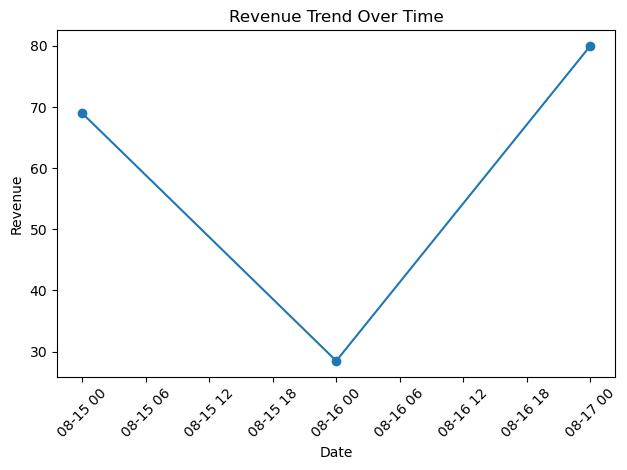

C:\Users\Debarati\AppData\Local\Temp\ipykernel_3752\864594667.py:79: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_roas = pd.read_sql(query_roas, conn)


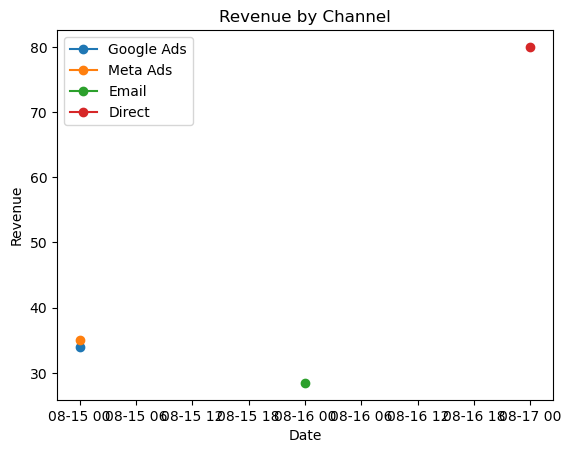

C:\Users\Debarati\AppData\Local\Temp\ipykernel_3752\864594667.py:107: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products = pd.read_sql(query_products, conn)


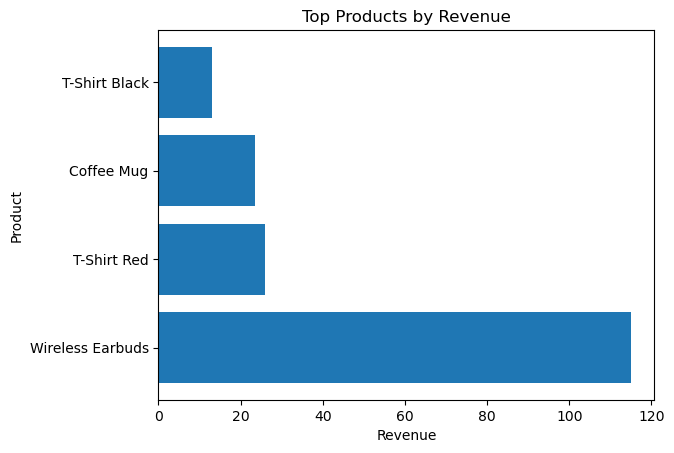

C:\Users\Debarati\AppData\Local\Temp\ipykernel_3752\864594667.py:129: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_geo = pd.read_sql(query_geo, conn)


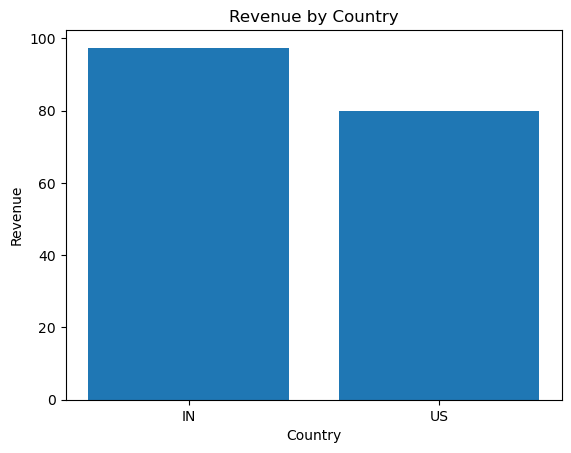

C:\Users\Debarati\AppData\Local\Temp\ipykernel_3752\864594667.py:151: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_refund = pd.read_sql(query_refund, conn)



Refund Data:
  refund_date  refunded_revenue
0  2025-08-18             12.99


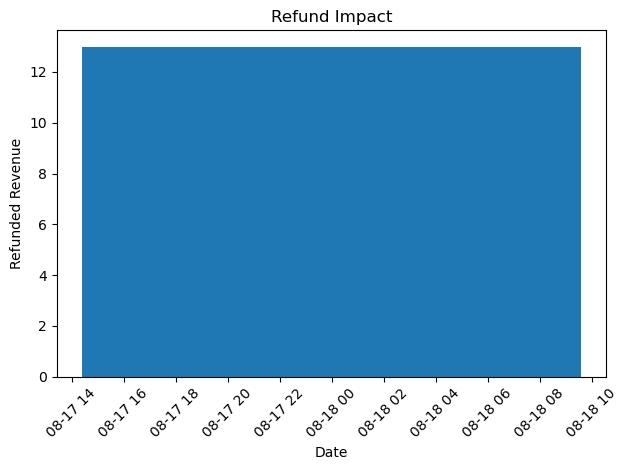


CAC Data:
            dt channel_name  total_spend  new_customers    cac
0   2025-08-15        Email         10.0            NaN    NaN
1   2025-08-16        Email         12.0            1.0   12.0
2   2025-08-17        Email          8.0            NaN    NaN
3   2025-08-18        Email         11.0            NaN    NaN
4   2025-08-19        Email          9.0            NaN    NaN
5   2025-08-15   Google Ads        120.0            1.0  120.0
6   2025-08-16   Google Ads        150.0            NaN    NaN
7   2025-08-17   Google Ads         90.0            NaN    NaN
8   2025-08-18   Google Ads        100.0            NaN    NaN
9   2025-08-19   Google Ads        110.0            NaN    NaN
10  2025-08-15     Meta Ads         80.0            1.0   80.0
11  2025-08-16     Meta Ads         60.0            NaN    NaN
12  2025-08-17     Meta Ads         90.0            NaN    NaN
13  2025-08-18     Meta Ads         70.0            NaN    NaN
14  2025-08-19     Meta Ads         85.0    

C:\Users\Debarati\AppData\Local\Temp\ipykernel_3752\864594667.py:203: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cac = pd.read_sql(query_cac, conn)


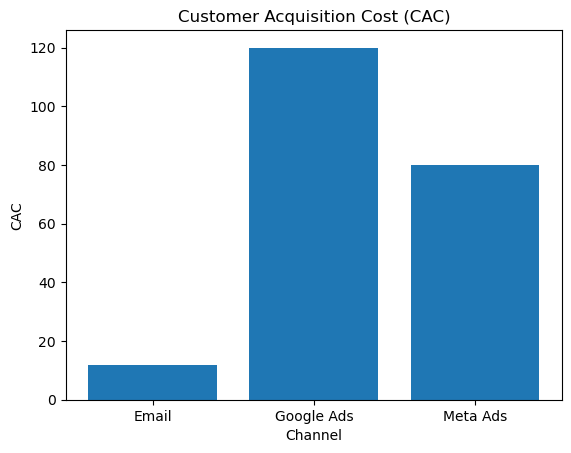

In [2]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1. CONNECT TO DATABASE
# ---------------------------
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="pass",
    database="ec",  
    port=3307
)

# ---------------------------
# 2. KPI SUMMARY
# ---------------------------
kpi_query = """
SELECT 
    COUNT(DISTINCT o.order_id) AS total_orders,
    SUM((oi.unit_price * oi.quantity) - IFNULL(oi.discount,0)) AS revenue,
    ROUND(AVG((oi.unit_price * oi.quantity) - IFNULL(oi.discount,0)),2) AS avg_order_value,
    SUM((oi.unit_price * oi.quantity) - IFNULL(oi.discount,0) - (p.cost_price * oi.quantity)) AS gross_margin,
    ROUND(
        SUM((oi.unit_price * oi.quantity) - IFNULL(oi.discount,0) - (p.cost_price * oi.quantity)) 
        / SUM((oi.unit_price * oi.quantity) - IFNULL(oi.discount,0)) * 100,2
    ) AS margin_percent
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
WHERE o.status = 'PAID';
"""

df_kpi = pd.read_sql(kpi_query, conn)

print("\n===== KPI SUMMARY =====")
print(df_kpi.T)

# ---------------------------
# 3. REVENUE TREND
# ---------------------------
query_trend = """
SELECT 
    DATE(order_datetime) AS dt,
    SUM((oi.unit_price * oi.quantity) - IFNULL(oi.discount,0)) AS revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.status = 'PAID'
GROUP BY dt;
"""

df_trend = pd.read_sql(query_trend, conn)

plt.figure()
plt.plot(df_trend['dt'], df_trend['revenue'], marker='o')
plt.title("Revenue Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------
# 4. REVENUE BY CHANNEL
# ---------------------------
query_roas = """
SELECT 
    DATE(o.order_datetime) AS order_date,
    c.channel_name,
    SUM((oi.unit_price * oi.quantity) - IFNULL(oi.discount,0)) AS revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN channels c ON o.channel_id = c.channel_id
WHERE o.status = 'PAID'
GROUP BY order_date, c.channel_name;
"""

df_roas = pd.read_sql(query_roas, conn)

plt.figure()
for channel in df_roas['channel_name'].unique():
    subset = df_roas[df_roas['channel_name'] == channel]
    plt.plot(subset['order_date'], subset['revenue'], marker='o', label=channel)

plt.title("Revenue by Channel")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

# ---------------------------
# 5. TOP PRODUCTS
# ---------------------------
query_products = """
SELECT 
    p.product_name,
    SUM((oi.unit_price * oi.quantity) - IFNULL(oi.discount,0)) AS revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
WHERE o.status = 'PAID'
GROUP BY p.product_name
ORDER BY revenue DESC;
"""

df_products = pd.read_sql(query_products, conn)

plt.figure()
plt.barh(df_products['product_name'], df_products['revenue'])
plt.title("Top Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

# ---------------------------
# 6. REVENUE BY COUNTRY
# ---------------------------
query_geo = """
SELECT 
    ship_country,
    SUM((oi.unit_price * oi.quantity) - IFNULL(oi.discount,0)) AS revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.status = 'PAID'
GROUP BY ship_country;
"""

df_geo = pd.read_sql(query_geo, conn)

plt.figure()
plt.bar(df_geo['ship_country'], df_geo['revenue'])
plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

# ---------------------------
# 7. REFUND IMPACT
# ---------------------------
query_refund = """
SELECT 
    DATE(o.order_datetime) AS refund_date,
    SUM((oi.unit_price * oi.quantity) - IFNULL(oi.discount,0)) AS refunded_revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.status = 'REFUNDED'
GROUP BY refund_date;
"""

df_refund = pd.read_sql(query_refund, conn)

print("\nRefund Data:")
print(df_refund)

if not df_refund.empty:
    plt.figure()
    plt.bar(df_refund['refund_date'], df_refund['refunded_revenue'])
    plt.title("Refund Impact")
    plt.xlabel("Date")
    plt.ylabel("Refunded Revenue")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No refund data available")

# ---------------------------
# 8. CAC (Customer Acquisition Cost)
# ---------------------------
query_cac = """
WITH new_customers AS (
    SELECT 
        o.channel_id,
        DATE(o.order_datetime) AS dt,
        COUNT(DISTINCT o.customer_id) AS new_customers
    FROM orders o
    WHERE o.status = 'PAID'
    GROUP BY o.channel_id, dt
),

spend AS (
    SELECT 
        channel_id,
        spend_date AS dt,
        SUM(spend) AS total_spend
    FROM channel_spend
    GROUP BY channel_id, dt
)

SELECT 
    s.dt,
    c.channel_name,
    s.total_spend,
    nc.new_customers,
    ROUND(s.total_spend / NULLIF(nc.new_customers,0),2) AS cac
FROM spend s
LEFT JOIN new_customers nc 
    ON s.channel_id = nc.channel_id AND s.dt = nc.dt
JOIN channels c ON c.channel_id = s.channel_id;
"""

df_cac = pd.read_sql(query_cac, conn)

print("\nCAC Data:")
print(df_cac)

# Handle NULL values
df_cac['cac'] = df_cac['cac'].fillna(0)

plt.figure()
plt.bar(df_cac['channel_name'], df_cac['cac'])
plt.title("Customer Acquisition Cost (CAC)")
plt.xlabel("Channel")
plt.ylabel("CAC")
plt.show()

# ---------------------------
# CLOSE CONNECTION
# ---------------------------
conn.close()

INSIGHTS

1. KPI Summary (Overall Performance)

The business generated steady revenue with a positive gross margin, indicating healthy unit economics.
The Average Order Value (AOV) suggests moderate basket size, meaning customers are not purchasing in bulk.
Margin % indicates profitability after cost, and if stable, suggests pricing is sustainable.



2. Revenue Trend Over Time

Revenue shows fluctuations across dates rather than a consistent upward trend.
This suggests demand is not stable, possibly influenced by campaigns or limited data points.
No clear growth trajectory is visible yet.



3. Revenue by Channel

Certain channels contribute significantly more revenue than others.
This indicates uneven performance across marketing channels.
High-performing channels should receive more budget allocation.



4. CAC (Customer Acquisition Cost)

CAC values are inconsistent or low due to limited data.
In some cases, CAC may appear as zero or null, indicating missing alignment between spend and customer acquisition.
This highlights a data limitation rather than a business conclusion.

 

5. Top Products

A few products contribute disproportionately to total revenue.
This indicates a skewed product performance distribution.
These products should be prioritized for:
inventory
marketing
bundling strategies



6. Revenue by Country

Revenue is concentrated in specific geographies.
This suggests stronger demand or better reach in those regions.
Underperforming regions may need localized strategies.



7. Refund Impact

Refunds exist but are limited in volume.
Current refund impact on revenue is minimal.
However, even small refund trends should be monitored for quality or logistics issues.
